## Cats vs Dogs

## Imports

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np

In [5]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [9]:
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [10]:
import kaggle

## Download Datas

In [11]:
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    'mmaulanaaryo14/cats-and-dogs-filtered',
    path='../datas/dataset',
    unzip=True)



Dataset URL: https://www.kaggle.com/datasets/mmaulanaaryo14/cats-and-dogs-filtered


In [ ]:
# Присвоим переменным конкретные пути к директориям
base_dir = os.path.join(os.path.dirname('../datas/dataset/cats_and_dogs_datasets'), 'cats_and_dogs_filtered')
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')

In [29]:
train_cats_dir = os.path.join(train_dir, 'cats')
train_dogs_dir = os.path.join(train_dir, 'dogs')
validation_cats_dir = os.path.join(validation_dir, 'cats')
validation_dogs_dir = os.path.join(validation_dir, 'dogs')

## Data Structure

In [31]:
num_cats_tr = len(os.listdir(train_cats_dir))
num_dogs_tr = len(os.listdir(train_dogs_dir))

num_cats_val = len(os.listdir(validation_cats_dir))
num_dogs_val = len(os.listdir(validation_dogs_dir))

total_train = num_cats_tr + num_dogs_tr
total_val = num_cats_val + num_dogs_val

In [33]:
print(num_cats_tr)
print(num_dogs_tr)

1000
1000


In [34]:
print(num_cats_val)
print(num_dogs_val)

500
500


In [35]:
print(total_train)
print(total_val)

2000
1000


## Global Model's Params

In [ ]:
BATCH_SIZE = 100
IMG_SHAPE = 150  # размерность, в которую будет передведено входное изображение

## Подготовка данных

1. Прочитать изображение с диска
1. Декодировать сожержимое изображений и преобразовать в нужный формат с учетом RGB-профиля
1. Преобразовать к тензорам со значением с плавающей запятой
1. Произвести нормализацию значений тензора из интервала от 0 до 255 к интервалу от 0 до 1

Все эти операции можно выполнить с использованием `tf.keras.preprocessing.image.ImageDataGenerator`- класса

In [39]:
# Создание экземпляра класса: определяем генераторы для обучающе и валидационной выборок
train_image_generator = ImageDataGenerator(rescale=1./255)
validation_image_generator = ImageDataGenerator(rescale=1./255)

С помощью метода `flow_from_directory` загрузим изображения с диска, нормализуем данные и изменим размер изображений:

In [44]:
train_data_gen = train_image_generator.flow_from_directory(
    batch_size=BATCH_SIZE,
    directory=train_dir,
    shuffle=True,
    target_size=(IMG_SHAPE, IMG_SHAPE),
    class_mode='binary'
)

Found 2000 images belonging to 2 classes.


In [46]:
val_data_gen = validation_image_generator.flow_from_directory(
    batch_size=BATCH_SIZE,
    directory=validation_dir,
    shuffle=True,
    target_size=(IMG_SHAPE, IMG_SHAPE),
    class_mode='binary'
)

Found 1000 images belonging to 2 classes.


## Images Visualisation

In [63]:
# функция возвращает batch в виде кортежа, состоящего из двух массивов:
sample_training_images, _ = next(train_data_gen)

In [64]:
print(type(next(train_data_gen)))

<class 'tuple'>


In [65]:
# images
same_training_images.shape

(100, 150, 150, 3)

In [66]:
# labels
_.shape

(100,)

In [67]:
def plotImages(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()    

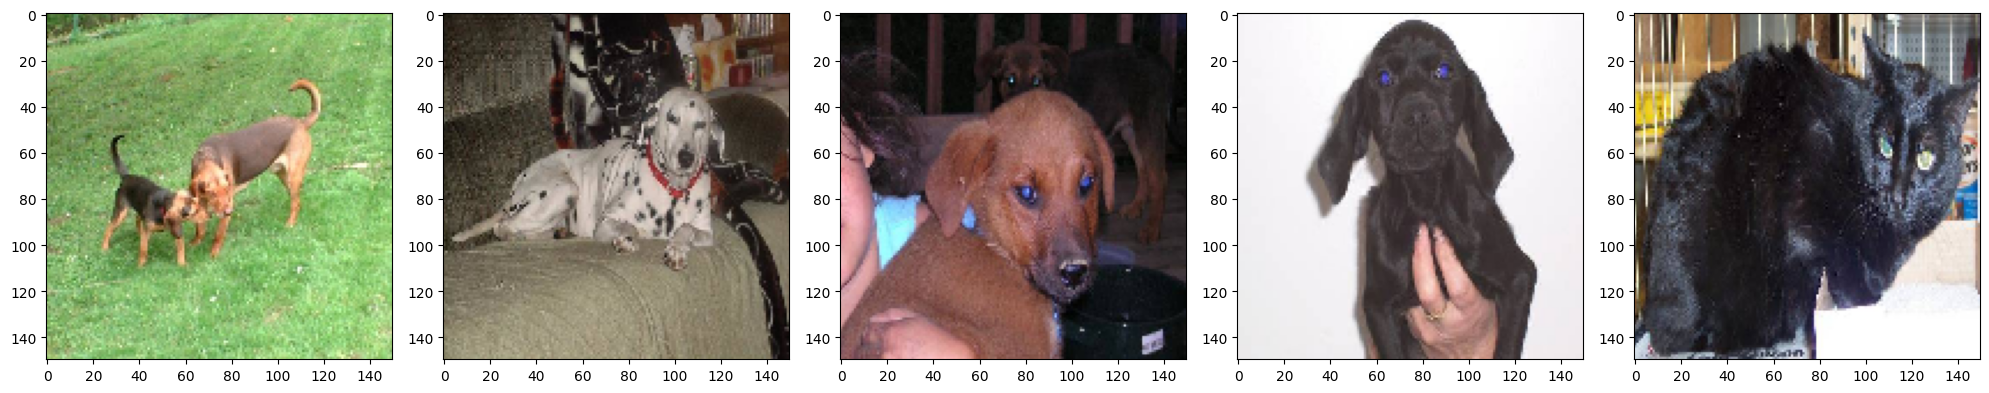

In [68]:
plotImages(sample_training_images[:5])

## Model Generation

### Model Prescription

In [89]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_SHAPE, IMG_SHAPE, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    # tf.keras.layers.Dense(2, activation='softmax')
    tf.keras.layers.Dense(1, activation='sigmoid')
])

In [90]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,453,121 (13.17 MB)

 Trainable params: 3,453,121 (13.17 MB)

 Non-trainable params: 0 (0.00 B)

### Model Compile

In [92]:
model.compile(
    optimizer='adam',
    # loss='sparse_categorical_crossentropy',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Model Training

In [ ]:
EPOCHS = 5
history = model.fit(
    train_data_gen,
    steps_per_epoch=int(np.ceil(total_train / float(BATCH_SIZE))),
    epochs=EPOCHS,
    validation_data=val_data_gen,
    validation_steps=int(np.ceil(total_val / float(BATCH_SIZE)))
)

Epoch 1/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.4783 - loss: 0.7171 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.5176 - loss: 0.6903 - val_accuracy: 0.6250 - val_loss: 0.6665
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.5892 - loss: 0.6652 - val_accuracy: 0.6610 - val_loss: 0.6269
Epoch 4/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 58s 3s/step - accuracy: 0.6238 - loss: 0.6377 - val_accuracy: 0.6640 - val_loss: 0.6124
Epoch 5/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6508 - loss: 0.6104 - val_accuracy: 0.6820 - val_loss: 0.5862


: 

### Training process visualisation

In [81]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [83]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

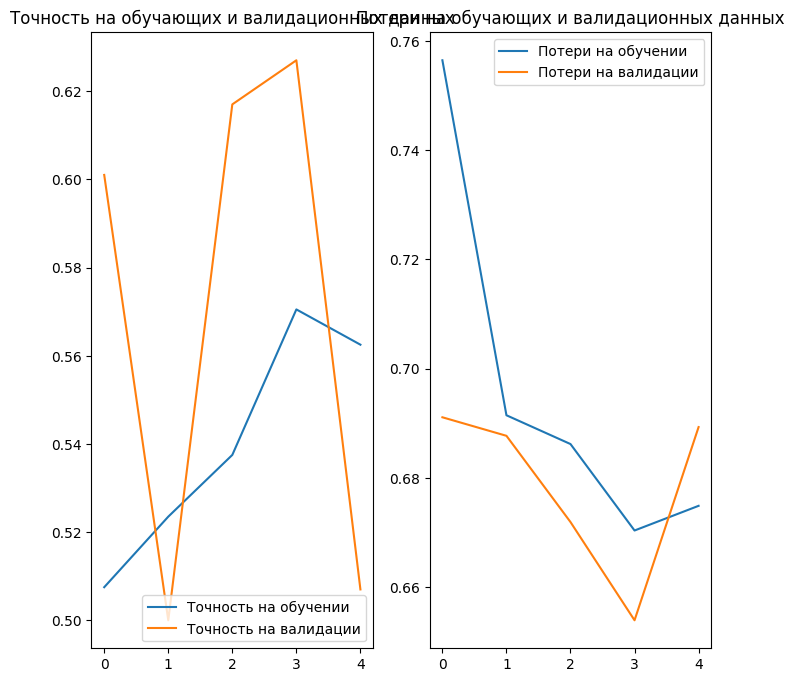

In [86]:
epochs_range = range(EPOCHS)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Точность на обучении')
plt.plot(epochs_range, val_acc, label='Точность на валидации')
plt.legend(loc='lower right')
plt.title('Точность на обучающих и валидационных данных')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Потери на обучении')
plt.plot(epochs_range, val_loss, label='Потери на валидации')
plt.legend(loc='upper right')
plt.title('Потери на обучающих и валидационных данных')
# plt.savefig('./foo.png')
plt.show()